# IEA22-280 Wind Blade cross-section

This tutorial homogenizes the **[IEA-22-280-RWT](https://github.com/IEAWindSystems/windIO)** reference
wind-turbine blade — its windIO description ships in the [windIO](https://github.com/IEAWindSystems/windIO)
repository (`examples/turbine/`). Section 1 below regenerates the 1-D shell cross-sections from that windIO
file **live** with the vendored [OpenSG_io](https://github.com/bagla0/OpenSG_io) converter; the homogenization
then reads the bundled **1-D shell** (`examples/data/iea_blade/`) and **2-D solid**
(`examples/data/2d_yaml/`) YAMLs directly. We homogenize eight span stations and compare the
**Reissner–Mindlin (RM)** and **Kirchhoff–Love (KL)** shell Timoshenko 6×6 against the **2-D solid**.

**Timoshenko 6×6 — VABS `.K` order:** 1 = extension, 2–3 = transverse shear, 4 = torsion, 5–6 = bending
(so C11 = EA, C22/C33 = GA2/GA3, C44 = GJ, C55/C66 = EI2/EI3; off-diagonal Cij are the couplings). This
ordering is used throughout — terms are referred to by their Cij index.

**Span station r:** the nondimensional spanwise station along the blade (fraction of span), from r = 0.2
(root region) to r = 0.9 (toward the tip).

In [1]:
import os, sys, time
import numpy as np
def _find_repo_root(d=None):
    d = os.path.abspath(d or os.getcwd())
    while True:
        if os.path.isdir(os.path.join(d, "examples", "data")) and os.path.isfile(os.path.join(d, "pyproject.toml")):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            raise RuntimeError("OpenSG-TW repo root not found - run this notebook from inside the cloned repo")
        d = parent
CC = _find_repo_root()
for q in (CC, os.path.join(CC, "opensg_jax")):
    if q not in sys.path:
        sys.path.insert(0, q)
os.environ["CUDA_VISIBLE_DEVICES"] = ""
import jax; jax.config.update("jax_enable_x64", True)
np.set_printoptions(precision=4, linewidth=170, suppress=True)
from IPython.display import Image, display
from opensg_jax.fe_jax.timo_report import sym, full_pcterr, compare_terms, nonzero_terms, wall_t, LBL
from opensg_jax.fe_jax.strip_RM import rm_timoshenko_6x6
from opensg_jax.fe_jax.gradient_kirchhoff import gradient_junction_kirchhoff
from opensg_jax.fe_jax.solid_timo import compute_timo_from_yaml
from opensg_jax.fe_jax.blade_viz import build_layup_registry, plot_layup_section, plot_orientation_montage, plot_span_loft
IB  = os.path.join(CC, "examples", "data", "iea_blade")
D2  = os.path.join(CC, "examples", "data", "2d_yaml")
IMG = os.path.join(CC, "docs", "tutorials", "_img")
STATIONS = [("r020", 0.2), ("r030", 0.3), ("r040", 0.4), ("r050", 0.5),
            ("r060", 0.6), ("r070", 0.7), ("r080", 0.8), ("r090", 0.9)]
SHELLS = [os.path.join(IB, "shell_%s.yaml" % t) for t, _ in STATIONS]
RR = [r for _, r in STATIONS]
REG = build_layup_registry(SHELLS)                       # global layup colour registry (same ply-stack -> same colour)
def rm_kl_solid(tag):
    shell = os.path.join(IB, "shell_%s.yaml" % tag)
    S = sym(np.loadtxt(os.path.join(IB, "C6_solid_%s.txt" % tag)))
    T = wall_t(shell)
    RM = sym(rm_timoshenko_6x6(shell, 0.0, dshift=T / 2, curved=False, shear="mitc", orient=False))
    KL = sym(gradient_junction_kirchhoff(shell, frac=0.0, dshift=T / 2, orient=False)[0])
    return S, RM, KL
print("ready | jax", jax.__version__, "| stations:", [t for t, _ in STATIONS], "| layups:", REG[1])

ready | jax 0.9.2 | stations: ['r020', 'r030', 'r040', 'r050', 'r060', 'r070', 'r080', 'r090'] | layups: ['glass-uniax', 'foam (skin)', 'carbon-uniax', 'foam (web)']


## 1 · How the cross-sections were created (windIO → OpenSG)

The 1-D shell SG YAMLs are generated **live** from the source [windIO](https://github.com/IEAWindSystems/windIO) blade file with the vendored [OpenSG_io](https://github.com/bagla0/OpenSG_io) converter — `load_blade` → `build_cross_section(r)` → `emit_opensg_yaml`, once per span station. The 2-D solid SG YAMLs add a **PreVABS** meshing step (`emit_prevabs` → `prevabs --vabs --hm` → `convert_sg_to_yaml`; that binary step is committed). The sections below read the bundled YAMLs from `examples/data/`.

In [2]:
sys.path.insert(0, os.path.join(CC, "third_party", "OpenSG_io"))
from opensg_io import load_blade, build_cross_section, emit_opensg_yaml
import yaml
WINDIO = os.path.join(CC, "examples", "data", "windio", "IEA-22-280-RWT.yaml")     # the windIO blade file
GEN = os.path.join(CC, "docs", "tutorials", "_gen"); os.makedirs(GEN, exist_ok=True)
blade = load_blade(WINDIO)                                    # windIO v2 reader (once for the whole blade)
print("windIO -> OpenSG 1-D shell SG, one cross-section per station:")
print("  %-4s %8s %8s %11s" % ("r", "chord", "elems", "laminates"))
for tag, r in STATIONS:
    cs = build_cross_section(blade, r=r, mesh_size=0.01)      # resolve laminates + webs at this station
    emit_opensg_yaml(cs, os.path.join(GEN, "shell_%s.yaml" % tag))
    d = yaml.safe_load(open(os.path.join(GEN, "shell_%s.yaml" % tag)))
    print("  %-4.1f %8.3f %8d %11d" % (r, cs["chord"], len(d["elements"]), len(d["sets"]["element"])))
print("\nThese reproduce the bundled examples/data/iea_blade/shell_*.yaml used below.")

windIO -> OpenSG 1-D shell SG, one cross-section per station:
  r       chord    elems   laminates


  0.2     7.200      315           6


  0.3     6.703      303           6


  0.4     5.834      294           6


  0.5     4.861      277           6


  0.6     3.947      272           7


  0.7     3.181      263           6


  0.8     2.584      258           6


  0.9     2.065      254           6

These reproduce the bundled examples/data/iea_blade/shell_*.yaml used below.


## 2 · Cross-section geometry & layup (r = 0.5)

The 2-D solid mesh and the 1-D shell line mesh, coloured by layup (same ply-stack → same colour). One **e2** (blue, in-plane ply) / **e3** (black, wall normal) arrow is drawn per structural region — the carbon spar caps, foam-cored skin panels, shear webs and glass-UD edge reinforcements.

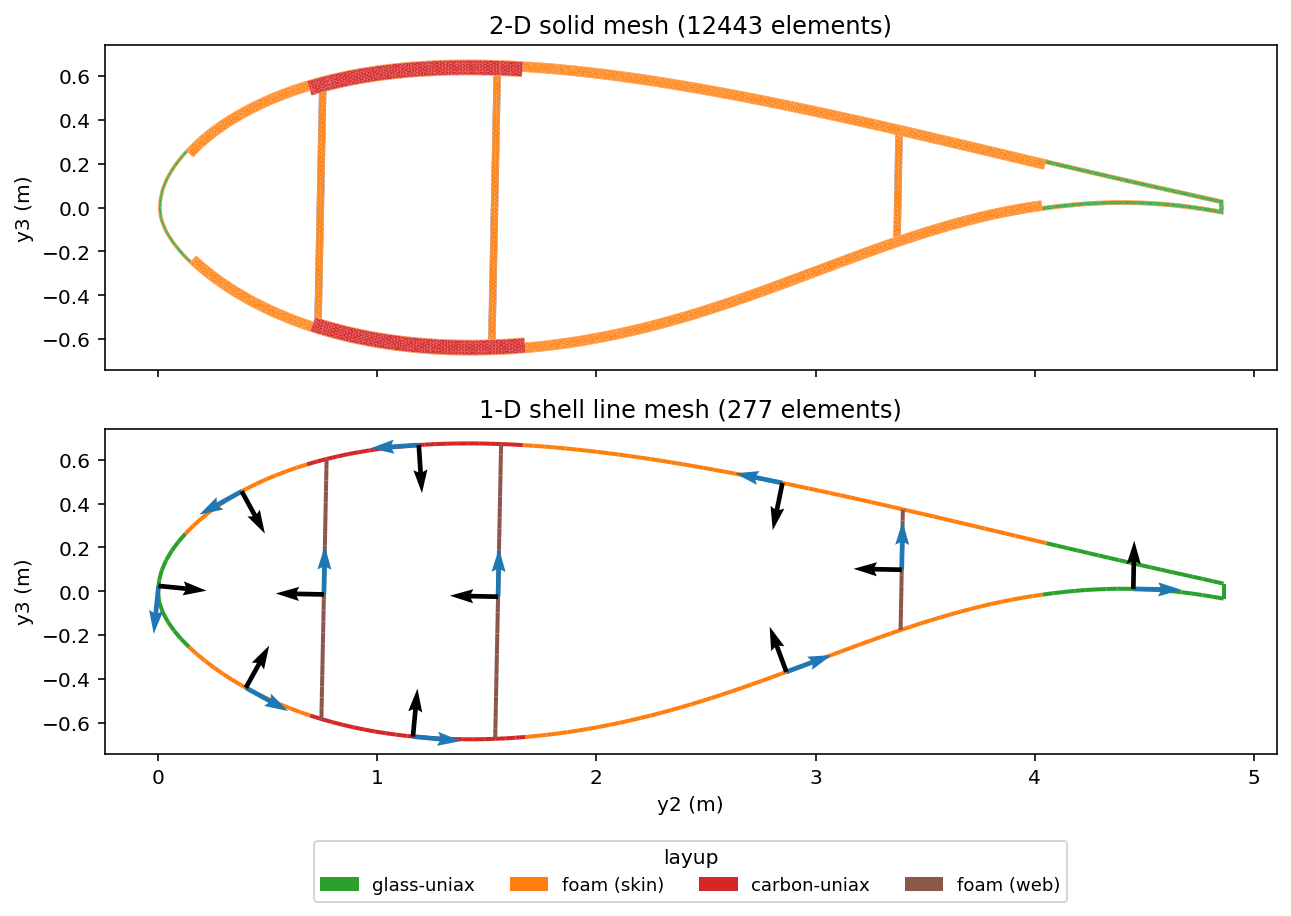

In [3]:
png = plot_layup_section(os.path.join(IB, "shell_r050.yaml"),
                         os.path.join(D2, "iea22_r050_solid.yaml"), REG,
                         os.path.join(IMG, "iea_layup_r050.png"))
Image(filename=png)

## 3 · Material orientation along the span

The line cross-section and material orientation at every station, split root / tip for clarity; layup colours match section 2.

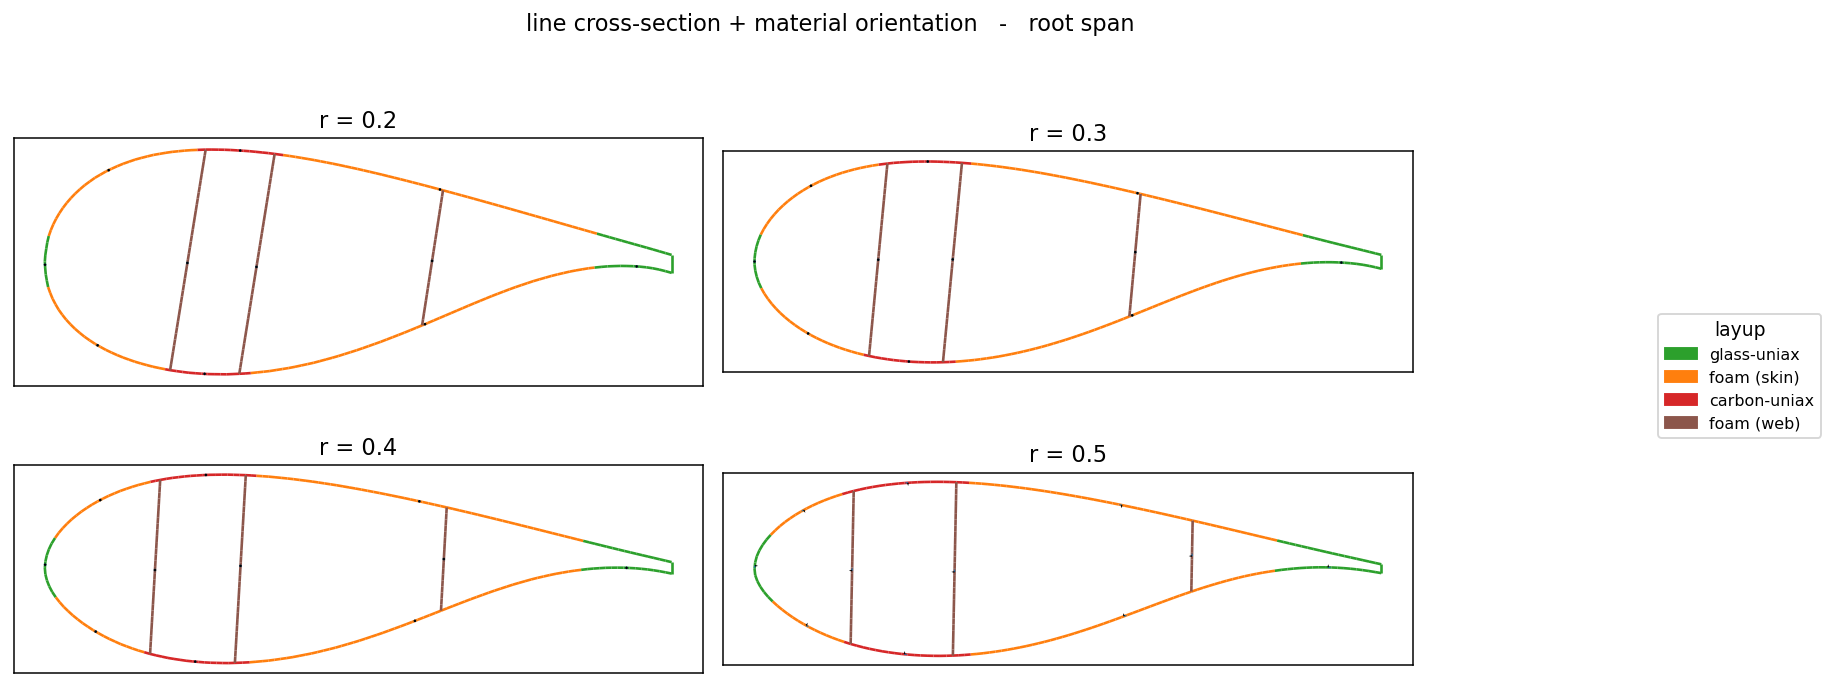

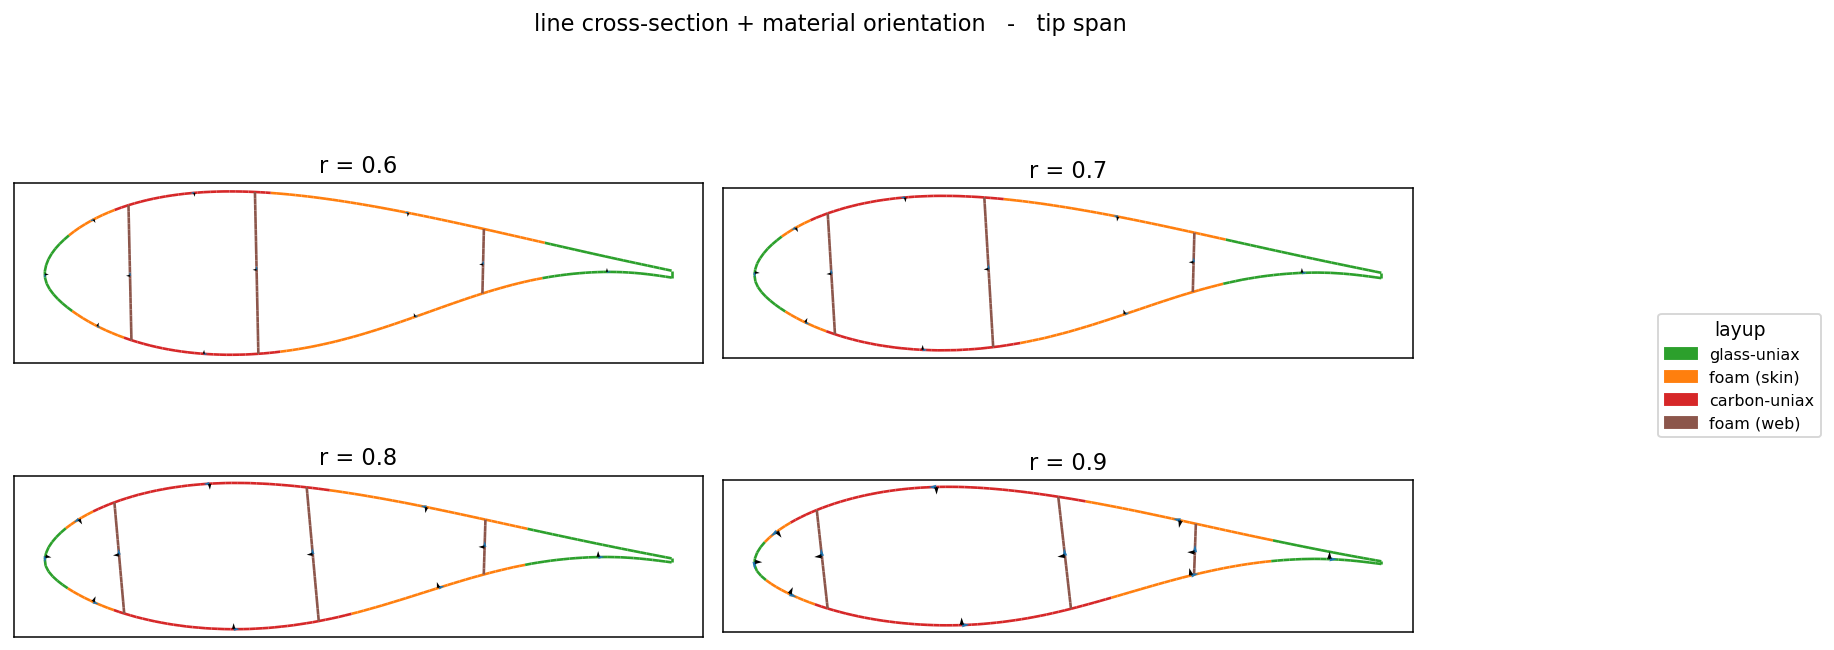

In [4]:
proot = plot_orientation_montage(SHELLS[:4], RR[:4], REG, os.path.join(IMG, "iea_montage_root.png"), title="root span")
ptip  = plot_orientation_montage(SHELLS[4:], RR[4:], REG, os.path.join(IMG, "iea_montage_tip.png"),  title="tip span")
display(Image(filename=proot)); display(Image(filename=ptip))

## 4 · Cross-sections lofted along the beam axis

The eight line cross-sections placed at their span stations r — the blade tapers and the carbon spar caps run out toward the tip.

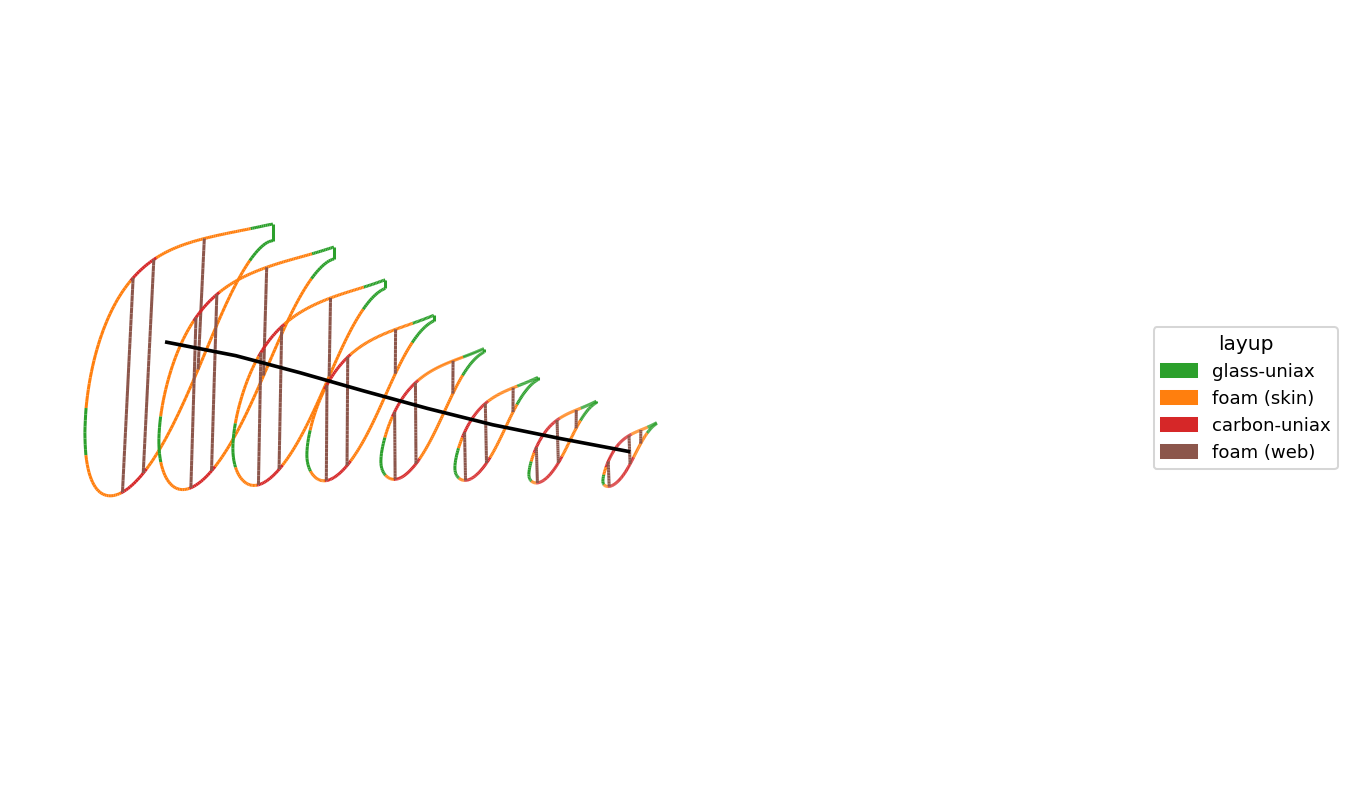

In [5]:
png = plot_span_loft(SHELLS, RR, REG, os.path.join(IMG, "iea_span_loft.png"))
Image(filename=png)

## 5 · Mid-span r = 0.5 — RM & KL vs 2-D solid, with solve times

Full 6×6 for the 2-D solid, RM and KL, the wall-clock solve time of each, and the per-Cij comparison. The 1-D shells cost a fraction of the 2-D solid.

In [6]:
shell = os.path.join(IB, "shell_r050.yaml"); T = wall_t(shell)
rm_timoshenko_6x6(shell, 0.0, dshift=T / 2, curved=False, shear="mitc", orient=False)      # warm-up (JIT)
gradient_junction_kirchhoff(shell, frac=0.0, dshift=T / 2, orient=False)                   # warm-up (JIT)
t0 = time.perf_counter(); RM = sym(rm_timoshenko_6x6(shell, 0.0, dshift=T / 2, curved=False, shear="mitc", orient=False)); t_rm = time.perf_counter() - t0
t0 = time.perf_counter(); KL = sym(gradient_junction_kirchhoff(shell, frac=0.0, dshift=T / 2, orient=False)[0]); t_kl = time.perf_counter() - t0
t0 = time.perf_counter(); SOL = sym(compute_timo_from_yaml(os.path.join(D2, "iea22_r050_solid.yaml"))); t_sol = time.perf_counter() - t0
S = sym(np.loadtxt(os.path.join(IB, "C6_solid_r050.txt")))
print("2-D solid (reference):"); print(S)
print("\nRM (1-D shell):"); print(RM)
print("\nKL (1-D shell):"); print(KL)
print("\nsolve time:   RM %.2f s    KL %.2f s    2-D solid %.1f s" % (t_rm, t_kl, t_sol))
print("\nr/R = 0.5  -  RM and KL vs the 2-D solid:")
compare_terms(S, {"RM": RM, "KL": KL})

V=7162 E=12443 primal_dofs=21486 Q=3


2-D solid (reference):
[[ 2.1520e+10  0.0000e+00  0.0000e+00  0.0000e+00  2.5900e+08 -3.0659e+10]
 [ 0.0000e+00  5.2213e+08  5.7317e+06 -1.3604e+07  0.0000e+00  0.0000e+00]
 [ 0.0000e+00  5.7317e+06  2.0441e+08  2.3289e+08  0.0000e+00  0.0000e+00]
 [ 0.0000e+00 -1.3604e+07  2.3289e+08  7.3482e+08  0.0000e+00  0.0000e+00]
 [ 2.5900e+08  0.0000e+00  0.0000e+00  0.0000e+00  7.2552e+09 -5.9046e+08]
 [-3.0659e+10  0.0000e+00  0.0000e+00  0.0000e+00 -5.9046e+08  6.1810e+10]]

RM (1-D shell):
[[ 2.1847e+10  0.0000e+00  0.0000e+00  0.0000e+00  2.5305e+08 -3.1121e+10]
 [ 0.0000e+00  5.3595e+08  5.9638e+06 -1.4453e+07  0.0000e+00  0.0000e+00]
 [ 0.0000e+00  5.9638e+06  1.9935e+08  2.3377e+08  0.0000e+00  0.0000e+00]
 [ 0.0000e+00 -1.4453e+07  2.3377e+08  7.6906e+08  0.0000e+00  0.0000e+00]
 [ 2.5305e+08  0.0000e+00  0.0000e+00  0.0000e+00  7.6023e+09 -5.7936e+08]
 [-3.1121e+10  0.0000e+00  0.0000e+00  0.0000e+00 -5.7936e+08  6.2958e+10]]

KL (1-D shell):
[[ 2.1847e+10 -1.4160e+03  5.4418e+02  6.

## 6 · Spanwise — transverse-shear terms & coupling vs r

The transverse-shear terms **C22 (GA2)**, **C33 (GA3)** and their coupling **C34 (GA3–GJ)** — where the two shell models differ most — across the span (**solid = RM, dotted = KL**). For the thin-walled skin both track the 2-D solid within a few %, with RM the closer of the two.

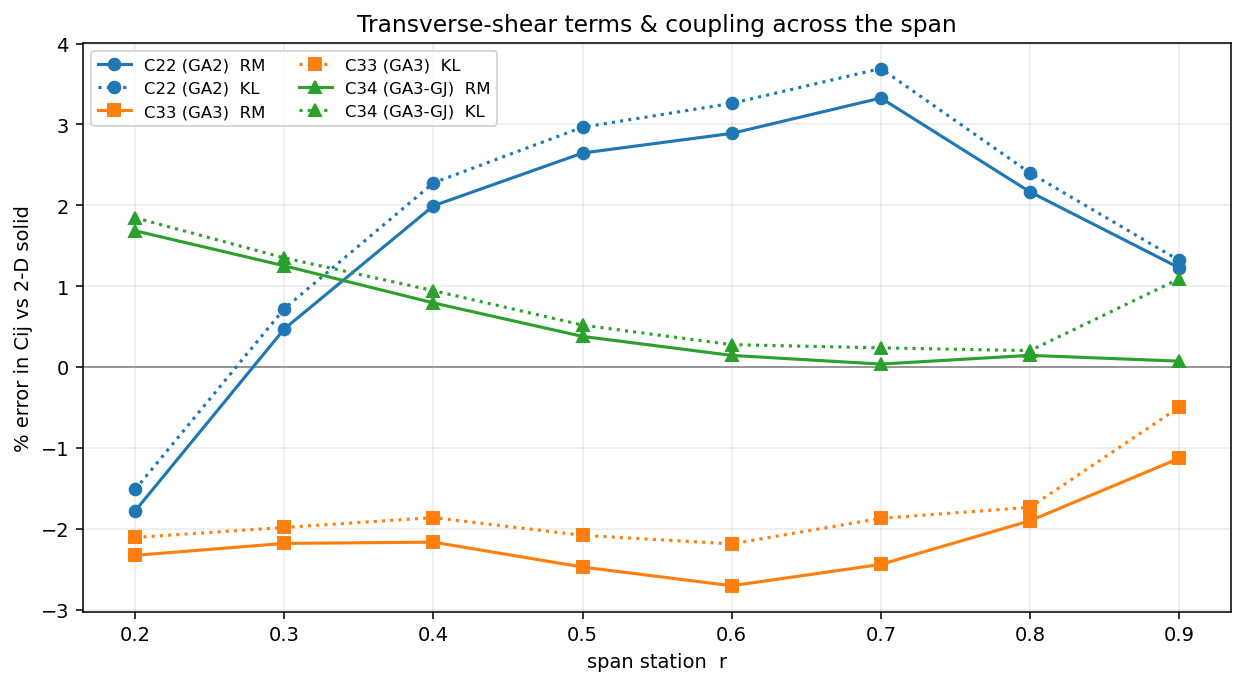

In [7]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
# transverse-shear terms C22 (GA2), C33 (GA3) and their coupling C34 (GA3-GJ) -- where RM and KL differ most
TERMS = [(1, 1, "C22 (GA2)"), (2, 2, "C33 (GA3)"), (2, 3, "C34 (GA3-GJ)")]
RMe, KLe = [], []
for tag, r in STATIONS:
    S, RM, KL = rm_kl_solid(tag)
    RMe.append([100.0 * (RM[i, j] - S[i, j]) / S[i, j] for i, j, _ in TERMS])
    KLe.append([100.0 * (KL[i, j] - S[i, j]) / S[i, j] for i, j, _ in TERMS])
RMe, KLe = np.array(RMe), np.array(KLe)
MARK = ["o", "s", "^"]; COL = ["tab:blue", "tab:orange", "tab:green"]
fig, ax = plt.subplots(figsize=(9, 5))
ax.axhline(0, color="0.5", lw=0.8)
for k, (i, j, tag) in enumerate(TERMS):
    ax.plot(RR, RMe[:, k], color=COL[k], marker=MARK[k], ls="-", lw=1.6, label="%s  RM" % tag)   # solid = RM
    ax.plot(RR, KLe[:, k], color=COL[k], marker=MARK[k], ls=":", lw=1.6, label="%s  KL" % tag)   # dotted = KL
ax.set_xlabel("span station  r"); ax.set_ylabel("% error in Cij vs 2-D solid")
ax.set_title("Transverse-shear terms & coupling across the span")
ax.grid(alpha=0.25)
ax.legend(fontsize=8.5, ncol=2, loc="best")                  # six curve-based entries (RM solid / KL dotted, per term)
p = os.path.join(IMG, "iea22_blade_span.png")
fig.tight_layout(); fig.savefig(p, dpi=140, bbox_inches="tight"); plt.close(fig)
Image(filename=p)

## Takeaway

For the thin-walled blade skin both shell models track the 2-D solid closely on the full 6×6, with **RM the better of the two on the transverse-shear terms** at every station — and at a fraction of the cost (RM ≈ 1 s, KL ≈ 3 s vs ≈ 15 s for the 2-D solid). Run the RM shell at every station to assemble the blade's 1-D beam model.